# Training Curves Plotting
Notebook per parsificare i log di training (`slurm-train-*.log`) e visualizzare le curve principali.

In [6]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
# Imposta il file di log desiderato; di default usa l'ultimo slurm-train-*.log
logs_dir = Path('../experiments/logs')
candidate_logs = sorted(logs_dir.glob('slurm-train-*.log'))

if not candidate_logs:
    raise FileNotFoundError(f'Nessun log trovato in {logs_dir.resolve()}')

log_path = candidate_logs[-1]
print(f'Using log file: {log_path}')

Using log file: ..\experiments\logs\slurm-train-4208.log


In [8]:
train_step_re = re.compile(
    r'^\[train\]\s+step=(?P<step>\d+)\s+samples=(?P<samples>\d+)\s+loss=(?P<loss>[0-9]*\.?[0-9]+)\s+acc=(?P<acc>[0-9]*\.?[0-9]+)'
)

epoch_re = re.compile(
    r'^\[epoch\s+(?P<epoch>\d+)\]\s+'
    r'train_loss=(?P<train_loss>[0-9]*\.?[0-9]+)\s+'
    r'train_acc=(?P<train_acc>[0-9]*\.?[0-9]+)\s+'
    r'val_map@1=(?P<val_map1>[0-9]*\.?[0-9]+)\s+'
    r'val_map@5=(?P<val_map5>[0-9]*\.?[0-9]+)\s+'
    r'val_map@10=(?P<val_map10>[0-9]*\.?[0-9]+)\s+'
    r'best=(?P<best>[0-9]*\.?[0-9]+)'
)

step_rows = []
epoch_rows = []

with log_path.open('r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()

        m_step = train_step_re.match(line)
        if m_step:
            row = m_step.groupdict()
            row['step'] = int(row['step'])
            row['samples'] = int(row['samples'])
            row['loss'] = float(row['loss'])
            row['acc'] = float(row['acc'])
            step_rows.append(row)
            continue

        m_epoch = epoch_re.match(line)
        if m_epoch:
            row = m_epoch.groupdict()
            row['epoch'] = int(row['epoch'])
            for k in ('train_loss', 'train_acc', 'val_map1', 'val_map5', 'val_map10', 'best'):
                row[k] = float(row[k])
            epoch_rows.append(row)

df_step = pd.DataFrame(step_rows).sort_values(['samples', 'step']).reset_index(drop=True)
df_epoch = pd.DataFrame(epoch_rows).sort_values('epoch').reset_index(drop=True)

print(f'Step records: {len(df_step)}')
print(f'Epoch records: {len(df_epoch)}')
df_epoch.tail()

Step records: 600
Epoch records: 100


,epoch,train_loss,train_acc,val_map1,val_map5,val_map10,best
95,96,0.8157,0.8205,0.5197,0.4023,0.3415,0.4023
96,97,0.8036,0.8232,0.5164,0.3984,0.3383,0.4023
97,98,0.7900,0.8267,0.5183,0.4005,0.3400,0.4023
98,99,0.7758,0.8295,0.5168,0.3996,0.3388,0.4023
99,100,0.7604,0.8335,0.5211,0.4030,0.3421,0.4030


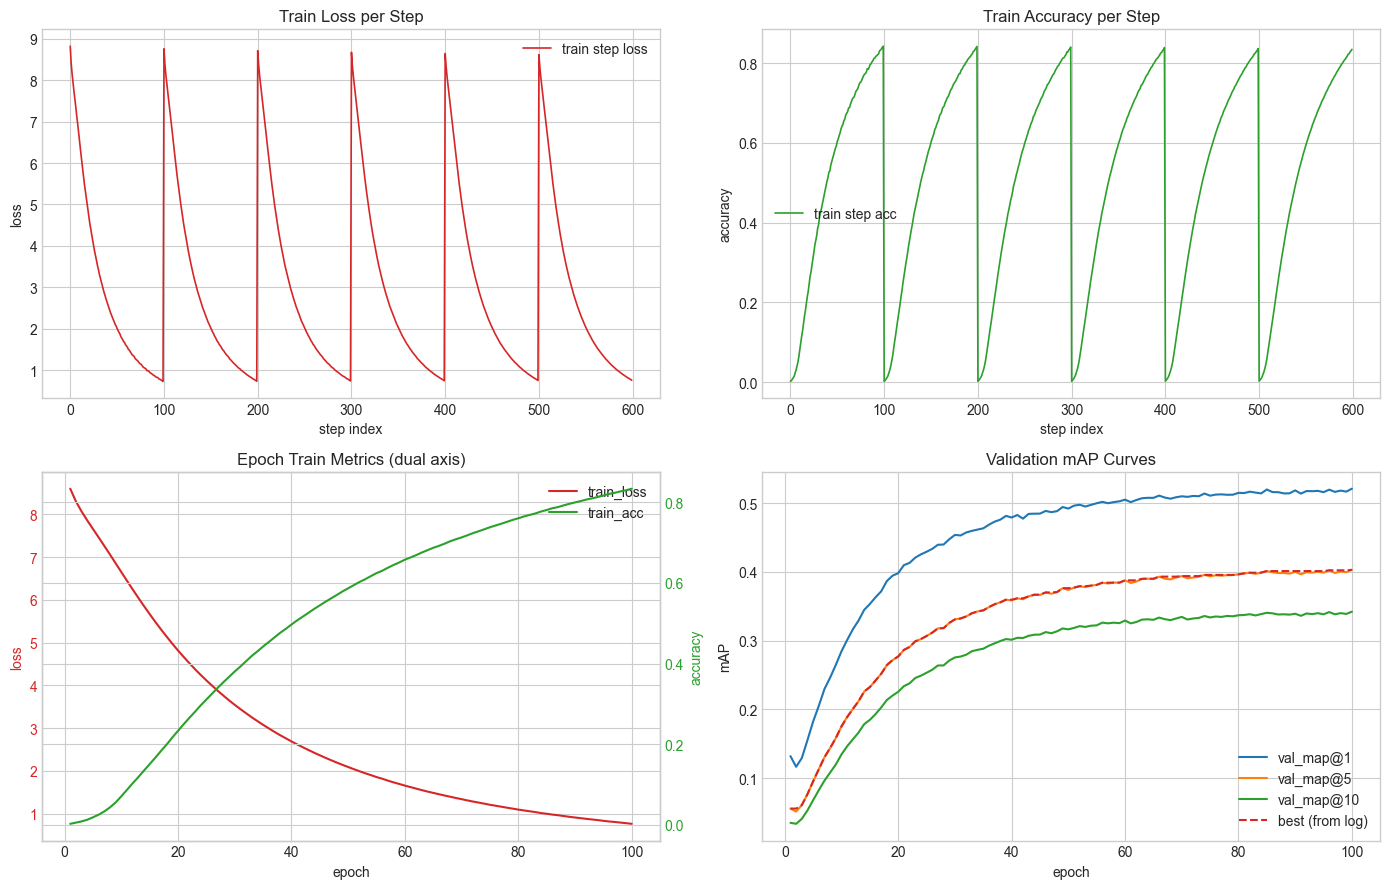

In [11]:
if df_step.empty and df_epoch.empty:
    raise ValueError('Nessuna metrica trovata nel log selezionato.')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

if not df_step.empty:
    axes[0, 0].plot(df_step.index, df_step['loss'], color='tab:red', linewidth=1.2, label='train step loss')
    axes[0, 0].set_title('Train Loss per Step')
    axes[0, 0].set_xlabel('step index')
    axes[0, 0].set_ylabel('loss')
    axes[0, 0].legend()

    axes[0, 1].plot(df_step.index, df_step['acc'], color='tab:green', linewidth=1.2, label='train step acc')
    axes[0, 1].set_title('Train Accuracy per Step')
    axes[0, 1].set_xlabel('step index')
    axes[0, 1].set_ylabel('accuracy')
    axes[0, 1].legend()
else:
    axes[0, 0].set_visible(False)
    axes[0, 1].set_visible(False)

if not df_epoch.empty:
    ax_epoch = axes[1, 0]
    ax_epoch_acc = ax_epoch.twinx()

    loss_line = ax_epoch.plot(
        df_epoch['epoch'],
        df_epoch['train_loss'],
        color='tab:red',
        label='train_loss',
    )
    acc_line = ax_epoch_acc.plot(
        df_epoch['epoch'],
        df_epoch['train_acc'],
        color='tab:green',
        label='train_acc',
    )

    ax_epoch.set_title('Epoch Train Metrics (dual axis)')
    ax_epoch.set_xlabel('epoch')
    ax_epoch.set_ylabel('loss', color='tab:red')
    ax_epoch_acc.set_ylabel('accuracy', color='tab:green')
    ax_epoch.tick_params(axis='y', labelcolor='tab:red')
    ax_epoch_acc.tick_params(axis='y', labelcolor='tab:green')

    lines = loss_line + acc_line
    labels = [line.get_label() for line in lines]
    ax_epoch.legend(lines, labels, loc='best')

    axes[1, 1].plot(df_epoch['epoch'], df_epoch['val_map1'], label='val_map@1')
    axes[1, 1].plot(df_epoch['epoch'], df_epoch['val_map5'], label='val_map@5')
    axes[1, 1].plot(df_epoch['epoch'], df_epoch['val_map10'], label='val_map@10')
    axes[1, 1].plot(df_epoch['epoch'], df_epoch['best'], linestyle='--', linewidth=1.5, label='best (from log)')
    axes[1, 1].set_title('Validation mAP Curves')
    axes[1, 1].set_xlabel('epoch')
    axes[1, 1].set_ylabel('mAP')
    axes[1, 1].legend()
else:
    axes[1, 0].set_visible(False)
    axes[1, 1].set_visible(False)

fig.tight_layout()
plt.show()

In [10]:
# Salvataggio opzionale figure
save_fig = False
output_path = Path('../figures/training_curves.png')

if save_fig:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'Figure salvata in: {output_path}')
else:
    print('save_fig=False: nessun file salvato')

save_fig=False: nessun file salvato
